### **Bagian 1: Pengumpulan Data**

* **Sumber Data**: Data opini publik diperoleh dari media sosial X (Twitter) menggunakan alat pencarian `tweet-harvest@2.6.1` berbasis runtime Node.js v20 (LTS). Pencarian dikonfigurasi menggunakan kata kunci "Makan Bergizi Gratis" pada linimasa twit terbaru (`--tab LATEST`).
* **Jumlah Sampel**: Dataset mentah gabungan memiliki total 1.040 baris data (sampel) yang tercatat dari indeks 0 hingga 1039.
* **Fitur-Fitur yang Ada**: Dataset hasil scraping ini memiliki total 15 kolom dengan rincian kegunaan sebagai berikut:


| # | Nama Kolom (Fitur) | Jumlah Non-Null | Tipe Data | Deskripsi Fungsi Fitur |
| :---: | :--- | :---: | :---: | :--- |
| **0** | `conversation_id_str` | 1040 | int64 | ID unik untaian percakapan (komentar bersambung). |
| **1** | `created_at` | 1040 | object | Waktu dan tanggal twit tersebut diunggah. |
| **2** | `favorite_count` | 1040 | int64 | Jumlah tanda suka (*likes*) yang didapat oleh twit. |
| **3** | **`full_text`** | **1040** | **object** | **Teks mentah opini/twit utama yang akan dianalisis.** |
| **4** | `id_str` | 1040 | int64 | ID unik berbasis string untuk setiap twit individu. |
| **5** | `image_url` | 701 | object | Tautan lampiran gambar di dalam twit (jika ada). |
| **6** | `in_reply_to_screen_name`| 199 | object | Nama pengguna (*username*) yang dibalas oleh twit ini. |
| **7** | `lang` | 1040 | object | Kode bahasa twit (contoh: 'in' untuk Indonesia). |
| **8** | `location` | 0 | float64 | Data lokasi geografis (seluruhnya kosong/null). |
| **9** | `quote_count` | 1040 | int64 | Jumlah berapa kali twit ini dikutip (*quoted tweet*). |
| **10**| `reply_count` | 1040 | int64 | Jumlah balasan komentar pada twit tersebut. |
| **11**| `retweet_count` | 1040 | int64 | Jumlah berapa kali twit disebarkan ulang (*retweet*). |
| **12**| `tweet_url` | 1040 | object | Tautan url langsung menuju twit asli di platform X. |
| **13**| `user_id_str` | 1040 | int64 | ID unik akun pengguna X yang menulis twit. |
| **14**| `username` | 0 | float64 | Nama akun pengguna (seluruhnya kosong/null). |

> **Catatan Teknis**: Dari keseluruhan fitur di atas, fitur **`full_text`** bertindak sebagai fitur prediktor utama (*feature input*) yang akan diproses pada tahap *Text Pre-processing* dan *Feature Engineering* menggunakan TF-IDF.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Tentukan path folder Anda
folder_path = '/content/drive/MyDrive/Dataset'

# Definisikan path untuk masing-masing file (asumsi format .csv)
path_a = folder_path + '/content/drive/MyDrive/Dataset/Makan_Bergizi_Gratis_05-06-2026_02-25-13.csv'
path_b = folder_path + '/content/drive/MyDrive/Dataset/Makan_Bergizi_Gratis_05-06-2026_03-02-32.csv'
path_c = folder_path + '/content/drive/MyDrive/Dataset/Makan_Bergizi_Gratis_05-06-2026_03-05-30.csv'

In [5]:
import pandas as pd

# Re-defining the paths correctly
file_name_a = 'Makan_Bergizi_Gratis_05-06-2026_02-25-13.csv'
file_name_b = 'Makan_Bergizi_Gratis_05-06-2026_03-02-32.csv'
file_name_c = 'Makan_Bergizi_Gratis_05-06-2026_03-05-30.csv'

# Using f-strings to construct the correct paths
path_a = f"{folder_path}/{file_name_a}"
path_b = f"{folder_path}/{file_name_b}"
path_c = f"{folder_path}/{file_name_c}"


# Membaca ketiga file
df_a = pd.read_csv(path_a)
df_b = pd.read_csv(path_b)
df_c = pd.read_csv(path_c)

# Menggabungkan secara vertikal (baris bertambah)
df_gabungan = pd.concat([df_a, df_b, df_c], ignore_index=True)

# Melihat info hasil penggabungan
print(df_gabungan.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      1040 non-null   int64  
 1   created_at               1040 non-null   object 
 2   favorite_count           1040 non-null   int64  
 3   full_text                1040 non-null   object 
 4   id_str                   1040 non-null   int64  
 5   image_url                701 non-null    object 
 6   in_reply_to_screen_name  199 non-null    object 
 7   lang                     1040 non-null   object 
 8   location                 0 non-null      float64
 9   quote_count              1040 non-null   int64  
 10  reply_count              1040 non-null   int64  
 11  retweet_count            1040 non-null   int64  
 12  tweet_url                1040 non-null   object 
 13  user_id_str              1040 non-null   int64  
 14  username                

In [6]:
df_gabungan['full_text']

,full_text
0,Rapidin Simbolon Usul Dana Makan Bergizi Grati...
1,What was supposed to be a standard presentatio...
2,Program Makan Bergizi Gratis terseret kasus ko...
3,Personel Polsek Krueng Sabee Laksanakan Samban...
4,Masa depan cerah Indonesia dimulai dari asupan...
...,...
1035,Wacana Program Makan Bergizi Gratis (MBG) bagi...
1036,Sekitar 9 orang penyidik Jaksa Agung Muda Tind...
1037,Program Makan Bergizi Gratis hadir untuk memba...
1038,Presiden Prabowo Subianto resmi menunjuk Nanik...


## **Bagian 2: Pra-Pemrosesan Teks (Text Pre-processing)**

Tahapan ini bertujuan untuk membersihkan data teks mentah (*noise*) dari platform X (Twitter) agar menjadi bentuk terstruktur yang optimal untuk dipelajari oleh model *Machine Learning*. Proses pra-pemrosesan dilakukan melalui 5 tahapan utama:

1. **Lowercasing**: Mengubah seluruh huruf menjadi huruf kecil (lowercase) agar kata yang sama dengan variasi kapitalisasi dinilai seragam (misal: "Makan", "MAKAN", dan "makan" dihitung sebagai satu token).
2. **Hapus Tanda Baca & Karakter Khusus (Regex Cleansing)**: Mengeliminasi komponen khas media sosial yang tidak membawa esensi makna topik, meliputi tautan URL (`https://...`), *mention* username (`@username`), simbol *hashtag* (`#`), angka, serta tanda baca.
3. **Tokenisasi**: Memecah rangkaian string kalimat panjang menjadi potongan kata-kata individu (*tokens*) menggunakan pustaka `NLTK`.
4. **Penghapusan Stopwords**: Membuang kata-kata umum dalam bahasa Indonesia yang frekuensi kemunculannya tinggi tetapi tidak memiliki bobot informatif khusus (seperti "yang", "di", "dan", "untuk") menggunakan korpus `NLTK`.
5. **Stemming**: Menghilangkan imbuhan pada kata (awalan, sisipan, akhiran) untuk mengembalikannya ke bentuk kata dasar menggunakan pustaka `Sastrawi` (misal: "berjalan" dan "melangkah" kembali menjadi "jalan" dan "langkah").

---

### **Contoh Teks Sebelum dan Sesudah Pra-Pemrosesan**

*   **Teks Sebelum (`full_text`):**
    > "@BGN_RI Uji coba program MBG (Makan Bergizi Gratis) hari ini berjalan lancar di 5 sekolah! 🍱 Menu makanannya sangat sehat. https://t.co"
*   **Teks Sesudah (`processed_tokens` / List format):**
    > `['uji', 'coba', 'program', 'mbg', 'makan', 'gizi', 'gratis', 'jalan', 'lancar', 'sekolah', 'menu', 'makan', 'sehat']`
*   **Teks Sesudah (`processed_text_clean` / String format):**
    > "uji coba program mbg makan gizi gratis jalan lancar sekolah menu makan sehat"


In [8]:
!pip install Sastrawi

In [9]:
import re
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Unduh library tokenisasi dan stopwords dari NLTK
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
# Download the missing 'punkt_tab' resource for NLTK's PunktTokenizer
nltk.download('punkt_tab')

# 1. Inisialisasi Stopwords Indonesia dan Stemmer Sastrawi
stop_words = set(stopwords.words('indonesian'))
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# 2. Fungsi Utama Pra-Pemrosesan
def preprocess_text(text):
    if not isinstance(text, str):
        return []

    # a. Lowercasing (Mengubah menjadi huruf kecil)
    text = text.lower()

    # b. Menghapus tanda baca, angka, URL, username (@), dan karakter khusus
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Hapus URL
    text = re.sub(r'@\w+', '', text)                 # Hapus mention X/Twitter
    text = re.sub(r'#\w+', '', text)                 # Hapus hashtag
    text = re.sub(r'[^a-zA-Z\s]', '', text)          # Hapus tanda baca & angka

    # c. Tokenisasi (Memecah kalimat menjadi kata)
    tokens = word_tokenize(text)

    # d. Penghapusan Stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # e. Stemming (Mengubah kata ke bentuk dasar)
    tokens = [stemmer.stem(word) for word in tokens]

    # Menghapus token kosong jika ada setelah proses stemming
    tokens = [word for word in tokens if word]

    return tokens

# 3. Terapkan fungsi ke kolom full_text
# Hasilnya berupa LIST kata sesuai struktur Tokenisasi
df_gabungan['processed_tokens'] = df_gabungan['full_text'].apply(preprocess_text)

# (Opsional) Jika ingin melihat dalam bentuk kalimat utuh kembali:
df_gabungan['processed_text_clean'] = df_gabungan['processed_tokens'].apply(lambda x: ' '.join(x))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [13]:
print(df_gabungan['full_text'])

0       Rapidin Simbolon Usul Dana Makan Bergizi Grati...
1       What was supposed to be a standard presentatio...
2       Program Makan Bergizi Gratis terseret kasus ko...
3       Personel Polsek Krueng Sabee Laksanakan Samban...
4       Masa depan cerah Indonesia dimulai dari asupan...
                              ...                        
1035    Wacana Program Makan Bergizi Gratis (MBG) bagi...
1036    Sekitar 9 orang penyidik Jaksa Agung Muda Tind...
1037    Program Makan Bergizi Gratis hadir untuk memba...
1038    Presiden Prabowo Subianto resmi menunjuk Nanik...
1039    Kepala Staf Kepresidenan (KSP) Dudung Abdurach...
Name: full_text, Length: 1040, dtype: object


In [14]:
print(df_gabungan['processed_tokens'])

0       [rapidin, simbolon, usul, dana, makan, gizi, g...
1       [what, was, supposed, to, be, a, standard, pre...
2       [program, makan, gizi, gratis, seret, korupsi,...
3       [personel, polsek, krueng, sabee, laksana, sam...
4       [cerah, indonesia, asupan, gizi, dukung, penuh...
                              ...                        
1035    [wacana, program, makan, gizi, gratis, mbg, si...
1036    [orang, sidik, jaksa, agung, muda, tindak, pid...
1037    [program, makan, gizi, gratis, hadir, bantu, a...
1038    [presiden, prabowo, subianto, resmi, nanik, su...
1039    [kepala, staf, presiden, ksp, dudung, abdurach...
Name: processed_tokens, Length: 1040, dtype: object


## **Bagian Tambahan: Pelabelan Otomatis Menggunakan Pendekatan Aturan Kata Kunci (Rule-Based Labeling)**

Karena dataset opini terkait program Makan Bergizi Gratis (MBG) hasil *scraping* dari X (Twitter) ini belum memiliki label kelas, proses pembuatan label target dilakukan menggunakan teknik **Rule-Based Labeling**. Teknik ini bekerja dengan mencocokkan kata kunci (*keyword matching*) yang merepresentasikan esensi dari setiap isu masalah strategis.

### **Metodologi dan Strategi Pengkondisian Aturan:**
Untuk mencegah terjadinya ketidakseimbangan data (*imbalanced data*) yang ekstrem akibat dominasi kata umum topik seperti "makan" atau "gizi", algoritma pelabelan ini menerapkan tiga strategi optimasi:
1. **Kamus Kata Kunci Spesifik Konteks X**: Menyusun daftar kosakata representatif untuk 4 pilar isu utama (`Ekonomi`, `Logistik`, `Politik`, dan `Kesehatan`), termasuk memasukkan kata-kata slang, ringkasan, atau nama tokoh terkait yang sering muncul di media sosial.
2. **Strategi Eksklusi Kelas Utama**: Menurunkan sensitivitas kata "makan" dan "gizi". Jika sebuah twit terdeteksi membahas isu `Ekonomi`, `Politik`, atau `Logistik`, sistem tidak akan otomatis mengelompokkannya ke dalam kelas `Kesehatan` hanya karena twit tersebut mengandung kata dasar "makan/gizi".
3. **Penanganan Kasus Ambigu**: Jika terjadi skor kecocokan kata kunci yang seimbang (*draw*) antar-kategori di luar kelas Kesehatan, sistem akan menetapkannya ke dalam label `Multitopik/Ambigu`. Kelas ambigu ini nantinya akan dieliminasi dari baris data sebelum masuk ke tahap pelatihan model agar tidak membingungkan proses pembelajaran model *Machine Learning*.


In [29]:
def tentukan_kategori_revisi(tokens):
    if not isinstance(tokens, list) or len(tokens) == 0:
        return 'Lainnya'

    teks = ' '.join(tokens)

    # Kamus kata kunci yang sudah diperluas dan disesuaikan bahasa X (Twitter)
    keywords = {
        'Ekonomi': [
            'apbn', 'anggaran', 'pajak', 'dana', 'subsidi', 'biaya', 'uang', 'mahal',
            'ekonomi', 'bayar', 'triliun', 'miliar', 'keuangan', 'fiskal', 'duit',
            'korupsi', 'korup', 'pangkas', 'utang', 'hutang', 'beban', 'fiskal'
        ],
        'Logistik': [
            'distribusi', 'pasok', 'susu', 'kirim', 'antar', 'kurir', 'logistik',
            'lambat', 'toko', 'warung', 'sedia', 'angkut', 'gudang', 'telat', 'macet',
            'vendor', 'supplier', 'daerah', 'pelosok', 'desa', 'sekolah', 'bagu'
        ],
        'Politik': [
            'politik', 'pemerintah', 'kampanye', 'presiden', 'menteri', 'oposisi',
            'rezim', 'kritik', 'janji', 'pimpinan', 'suara', 'dewan', 'dpr', 'kebijakan',
            'rakyat', 'gibran', 'prabowo', 'dinasti', 'pemilu', 'pilkada', 'partai'
        ],
        'Kesehatan': [
            # Menghapus 'makan' dan 'gizi' dari daftar utama agar tidak mendominasi
            'nutrisi', 'kalori', 'higienis', 'menu', 'porsi', 'vitamin', 'sehat',
            'bersih', 'sakit', 'racun', 'keracunan', 'daging', 'sayur', 'mubazir',
            'basi', 'susu', 'stunting', 'timbang', 'diet', 'higenis'
        ]
    }

    skor_kategori = {k: 0 for k in keywords.keys()}

    # Hitung kecocokan kata kunci
    for kategori, kata_kunci in keywords.items():
        skor_kategori[kategori] = sum(1 for kata in kata_kunci if kata in teks)

    # STRATEGI EKSKLUSI:
    # Jika twit punya kata kunci Ekonomi/Politik/Logistik, jangan biarkan kata "makan"
    # atau "gizi" secara otomatis membuat twit itu masuk ke kategori Kesehatan/Gizi.
    if skor_kategori['Ekonomi'] > 0 or skor_kategori['Politik'] > 0 or skor_kategori['Logistik'] > 0:
        # Jika kategori lain mendominasi atau setara, beri prioritas ke non-gizi
        pass
    else:
        # Kategori Kesehatan/Gizi hanya berhak mendapat poin tambahan jika murni membahas makanan
        if 'makan' in teks or 'gizi' in teks:
            skor_kategori['Kesehatan'] += 1

    skor_maksimal = max(skor_kategori.values())

    if skor_maksimal == 0:
        return 'Lainnya'

    kategori_terpilih = [kategori for kategori, skor in skor_kategori.items() if skor == skor_maksimal]

    if len(kategori_terpilih) > 1:
        # Jika seri antara Gizi dengan yang lain, prioritaskan yang non-Gizi demi keseimbangan data
        if 'Kesehatan' in kategori_terpilih:
            kategori_terpilih.remove('Kesehatan')
            if len(kategori_terpilih) == 1:
                return kategori_terpilih[0]
        return 'Multitopik/Ambigu'

    return kategori_terpilih[0]

# Eksekusi ulang
df_gabungan['label_kategori'] = df_gabungan['processed_tokens'].apply(tentukan_kategori_revisi)
print(df_gabungan['label_kategori'].value_counts())

label_kategori
Politik              324
Kesehatan            299
Ekonomi              259
Logistik              90
Multitopik/Ambigu     68
Name: count, dtype: int64


## **Bagian 3: Rekayasa Fitur (Feature Engineering)**

Tahapan rekayasa fitur bertujuan untuk mentransformasikan teks opini yang telah dibersihkan menjadi bentuk representasi numerik (vektor angka) agar dapat diproses oleh algoritma *Machine Learning*. Dua teknik ekstraksi fitur tekstual yang paling umum digunakan dalam NLP adalah TF-IDF dan Word2Vec.

### **1. Konsep TF-IDF (Term Frequency-Inverse Document Frequency)**
TF-IDF adalah metode statistik yang mengukur seberapa penting suatu kata di dalam sebuah dokumen (twit) relatif terhadap seluruh kumpulan dokumen (korpus). Bobot kalkulasinya merupakan perkalian dari dua komponen:
*   **Term Frequency (TF)**: Mengukur frekuensi kemunculan suatu kata di dalam satu twit tertentu. Semakin sering kata muncul, nilainya semakin tinggi.
*   **Inverse Document Frequency (IDF)**: Mengukur seberapa langka atau unik suatu kata di seluruh dataset. Kata yang muncul di hampir semua dokumen (seperti kata umum) akan diberi bobot rendah, sedangkan kata spesifik yang hanya muncul di twit tertentu (seperti "apbn", "stunting", atau "vendor") akan diberi bobot tinggi karena mengandung nilai informasi yang kuat.

### **2. Konsep Word2Vec (Word Embedding)**
Word2Vec adalah teknik berbasis jaringan saraf (*Neural Network*) dangkal yang memetakan setiap kata ke dalam ruang vektor berdimensi tinggi (biasanya 100-300 dimensi).
*   Berbeda dengan TF-IDF yang hanya menghitung frekuensi kata, Word2Vec mampu menangkap **makna semantik dan konteks kedekatan antar-kata** berdasarkan kata-kata di sekitarnya (*distributional hypothesis*).
*   Sebagai contoh, Word2Vec dapat memahami secara matematis bahwa vektor kata *"gizi"* dan *"nutrisi"*, atau *"anggaran"* dan *"apbn"* memiliki kedekatan jarak karena sering muncul dalam konteks kalimat yang mirip di platform X.

---

### **Desain Pipeline Ekstraksi Fitur TF-IDF yang Diterapkan:**
Pada sistem klasifikasi ini, ekstraksi fitur menggunakan pustaka `scikit-learn` dikonfigurasi secara ketat dengan parameter optimasi berikut:
*   **Filtrasi Data Bersih**: Menghapus kelas `Multitopik/Ambigu` dan `Lainnya` agar model hanya fokus mempelajari pola bahasa dari 4 kategori isu utama (`Ekonomi`, `Logistik`, `Politik`, dan `Kesehatan`).
*   **Stratified Train-Test Split**: Memisahkan data sebesar 80% untuk latihan (*Training*) dan 20% untuk pengujian (*Testing*) dengan parameter `stratify=y` guna menjamin proporsi sebaran label tetap adil dan seimbang di kedua bagian data.
*   **Kombinasi N-gram (1, 2)**: Mengekstrak kata tunggal (*unigram*) sekaligus pasangan kata berurutan (*bigram*, contoh: "susu gratis", "anggaran pangkas") untuk menangkap konteks kalimat pendek khas media sosial secara lebih utuh.
*   **Batas Fitur (max_features=3000)**: Membatasi matriks kosakata hanya pada 3.000 kata dengan bobot tertinggi untuk meningkatkan efisiensi memori dan komputasi model.


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Bersihkan dataset dari label 'Multitopik/Ambigu' dan 'Lainnya' jika ada
# Ini dilakukan agar model fokus belajar pada 4 kategori isu utama yang bersih
df_model = df_gabungan[~df_gabungan['label_kategori'].isin(['Multitopik/Ambigu', 'Lainnya'])].copy()

# 2. Gabungkan kembali list token menjadi satu string kalimat utuh
# TfidfVectorizer membutuhkan input berupa string teks, bukan list/array
df_model['text_clean'] = df_model['processed_tokens'].apply(lambda x: ' '.join(x))

# 3. Tentukan variabel Fitur (X) dan Target Label (y)
X = df_model['text_clean']
y = df_model['label_kategori']

# 4. Bagi dataset menjadi Data Training (80%) dan Data Testing (20%)
# Parameter stratify=y menjaga agar proporsi distribusi label tetap seimbang di kedua data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5. Inisialisasi TfidfVectorizer
# max_features=3000 membatasi kosakata hanya pada 3000 kata paling penting untuk menghemat memori
tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

# 6. Transformasikan teks menjadi matriks angka bobot TF-IDF
# fit_transform hanya digunakan pada data training untuk mempelajari pola kata
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
# transform digunakan pada data testing menggunakan pola kata yang sudah dipelajari sebelumnya
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 7. Cetak dimensi hasil rekayasa fitur
print("--- Hasil Rekayasa Fitur TF-IDF ---")
print(f"Dimensi Data Train (Baris, Jumlah Fitur Kata): {X_train_tfidf.shape}")
print(f"Dimensi Data Test  (Baris, Jumlah Fitur Kata): {X_test_tfidf.shape}")

--- Hasil Rekayasa Fitur TF-IDF ---
Dimensi Data Train (Baris, Jumlah Fitur Kata): (777, 3000)
Dimensi Data Test  (Baris, Jumlah Fitur Kata): (195, 3000)


## **Bagian 4: Analisis Data Eksploratif dan Visualisasi (EDA)**

Tahapan *Exploratory Data Analysis* (EDA) bertujuan untuk memahami karakteristik struktural dan pola sebaran kata di dalam dataset opini Makan Bergizi Gratis (MBG) sebelum masuk ke inti pemodelan klasifikasi. Pada bagian ini, analisis dan visualisasi dilakukan melalui tiga pendekatan:

### **1. Plot Distribusi Panjang Teks (Jumlah Kata per Dokumen)**
*   **Tujuan**: Mengetahui densitas atau seberapa ringkas informasi yang ditulis oleh pengguna platform X setelah melewati proses eliminasi *noise* (*preprocessing*).
*   **Analisis**: Visualisasi menggunakan grafik *histogram* dan kurva *KDE (Kernel Density Estimation)* membantu mendeteksi rata-rata jumlah kata bermakna inti yang tersisa di setiap dokumen, nilai minimum-maksimum panjang twit, serta mengidentifikasi apakah terdapat pencilan (*outliers*) data tekstual.

### **2. Bar Plot Frekuensi Kata-Kata Teratas (Top 20 Keywords)**
*   **Tujuan**: Memetakan daftar kosakata (*vocabulary*) yang paling mendominasi alur percakapan publik secara kuantitatif.
*   **Analisis**: Dengan mengekstraksi dan menghitung kemunculan kata dasar (*stemmed tokens*) menggunakan modul `Counter`, grafik diagram batang ini menampilkan 20 kata dengan frekuensi tertinggi. Representasi ini sangat penting untuk memvalidasi apakah kata kunci dominan sudah selaras dengan korpus topik MBG.

### **3. Word Cloud (Awan Kata)**
*   **Tujuan**: Menyediakan representasi visual intuitif mengenai topik utama yang sedang hangat dibahas oleh masyarakat.
*   **Analisis**: *Word Cloud* menyusun puluhan kata kunci secara acak di dalam satu kanvas gambar, di mana **skala ukuran (font size) suatu kata berbanding lurus dengan frekuensi kemunculannya** di dalam dataset. Semakin besar ukuran tulisan kata tersebut, maka kata tersebut merupakan inti dari dinamika opini publik terkait program MBG.


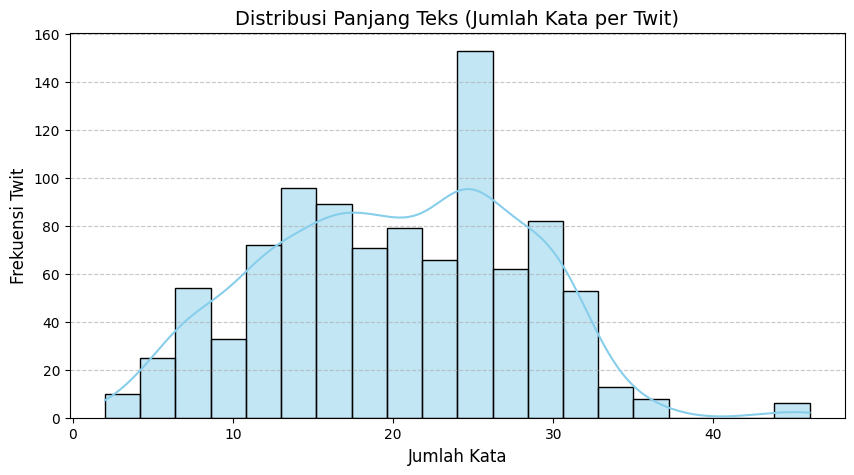

--- Statistik Panjang Kata ---
count    972.000000
mean      20.076132
std        7.892974
min        2.000000
25%       14.000000
50%       20.000000
75%       26.000000
max       46.000000
Name: jumlah_kata, dtype: float64


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah kata per dokumen/twit
df_model['jumlah_kata'] = df_model['processed_tokens'].apply(len)

# Plot distribusi panjang teks
plt.figure(figsize=(10, 5))
sns.histplot(df_model['jumlah_kata'], bins=20, kde=True, color='skyblue')

plt.title('Distribusi Panjang Teks (Jumlah Kata per Twit)', fontsize=14)
plt.xlabel('Jumlah Kata', fontsize=12)
plt.ylabel('Frekuensi Twit', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Tampilkan statistik deskriptif panjang kata
print("--- Statistik Panjang Kata ---")
print(df_model['jumlah_kata'].describe())

/tmp/ipykernel_4246/112706435.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata', data=df_kata_teratas, palette='viridis')


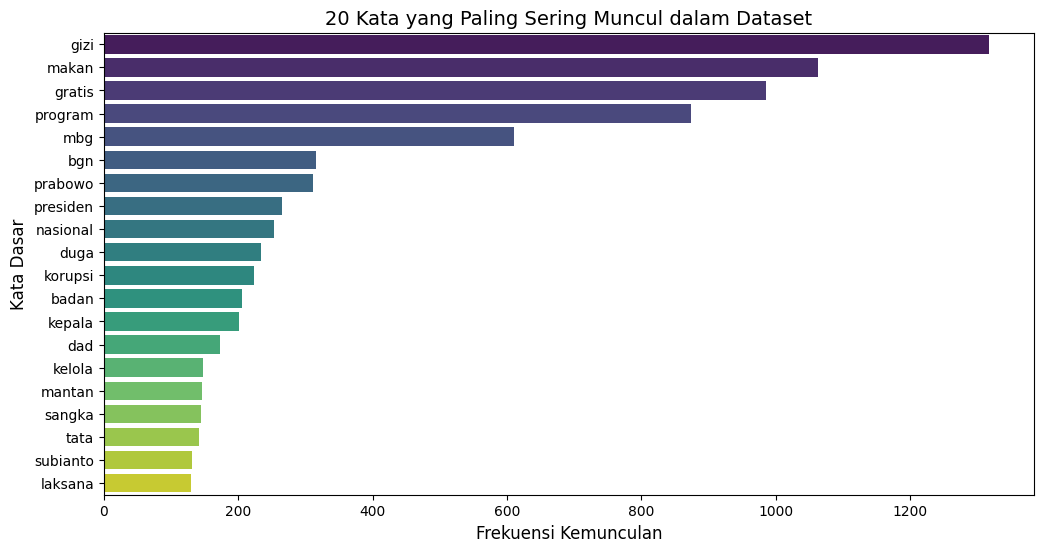

In [32]:
from collections import Counter
import pandas as pd

# Gabungkan semua token dari seluruh baris menjadi satu list besar
semua_kata = [kata for tokens in df_model['processed_tokens'] for kata in tokens]

# Hitung frekuensi kemunculan setiap kata
hitung_kata = Counter(semua_kata)

# Ambil 20 kata teratas
kata_teratas = hitung_kata.most_common(20)
df_kata_teratas = pd.DataFrame(kata_teratas, columns=['Kata', 'Frekuensi'])

# Visualisasikan dengan Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Frekuensi', y='Kata', data=df_kata_teratas, palette='viridis')

plt.title('20 Kata yang Paling Sering Muncul dalam Dataset', fontsize=14)
plt.xlabel('Frekuensi Kemunculan', fontsize=12)
plt.ylabel('Kata Dasar', fontsize=12)
plt.show()

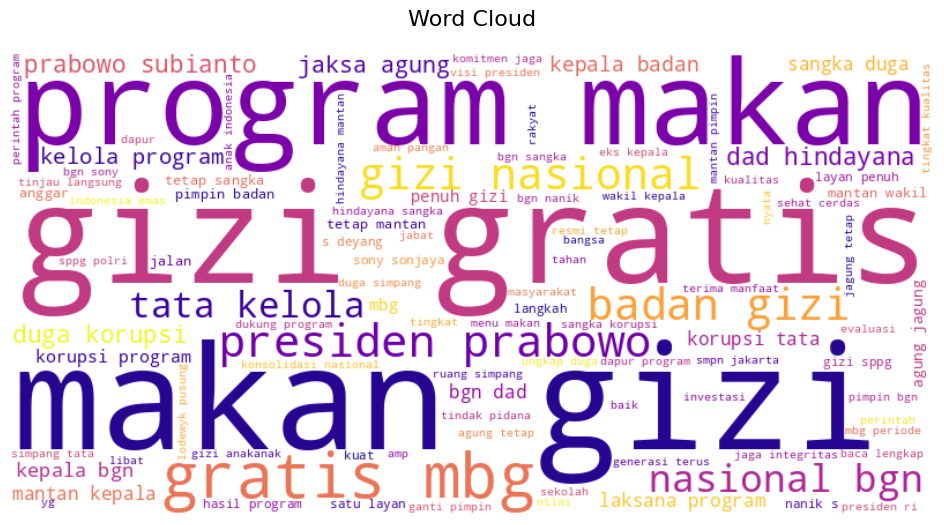

In [33]:
from wordcloud import WordCloud

# Gabungkan seluruh list kata menjadi satu string besar terpisah spasi
teks_wordcloud = ' '.join(semua_kata)

# Inisialisasi dan buat Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='plasma'
).generate(teks_wordcloud)

# Tampilkan Word Cloud menggunakan matplotlib
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Menghilangkan sumbu koordinat x dan y
plt.title('Word Cloud', fontsize=16, pad=20)
plt.show()

## **Bagian 5: Klasifikasi Teks**

Tahapan ini merupakan inti dari sistem cerdas yang dibangun, di mana representasi fitur numerik hasil ekstraksi **TF-IDF** dimasukkan ke dalam berbagai algoritma *supervised learning*. Tujuannya adalah untuk melatih model agar mampu mengenali pola kata unik dan melakukan pemetaan otomatis dokumen twit ke dalam 4 aspek target (`Ekonomi`, `Logistik`, `Politik`, atau `Kesehatan`).

### **1. Metodologi Eksperimen Perbandingan Algoritma**
Untuk menemukan performa model yang paling optimal dan objektif, penelitian ini menerapkan strategi **Multi-Classifier Benchmarking** dengan melatih dan membandingkan 5 algoritma lintas paradigma sekaligus:
*   **Naive Bayes (MultinomialNB)**: Algoritma probabilistik berbasis *Bayes Theorem*. Sangat cepat dan efisien untuk pemodelan teks karena mengasumsikan setiap bobot kata saling independen.
*   **Support Vector Machine (LinearSVC)**: Algoritma linier yang berfokus mencari *hyperplane* pembatas maksimal antar-kelas di ruang dimensi tinggi. Sangat tangguh untuk klasifikasi teks berbasis TF-IDF.
*   **Logistic Regression**: Model statistik linier yang memprediksi probabilitas probabilitas multikelas menggunakan fungsi *softmax*.
*   **Random Forest Classifier**: Algoritma berbasis *ensemble learning* yang mengombinasikan puluhan pohon keputusan (*decision trees*) acak guna meningkatkan stabilitas prediksi.
*   **XGBoost (Extreme Gradient Boosting)**: Algoritma modern berbasis *gradient boosted decision trees* yang terkenal sangat cepat dan memiliki akurasi tinggi melalui optimasi regularisasi formal.

### **2. Penanganan Ketidakseimbangan Data & Penyelarasan Label**
*   **Parameter `class_weight='balanced'`**: Diaktifkan pada SVM, Logistic Regression, dan Random Forest untuk memberikan bobot penalti lebih tinggi pada kelas minoritas (seperti isu `Logistik`), sehingga model tidak condong hanya menebak kelas mayoritas.
*   **Label Encoding**: Digunakan secara khusus untuk menyelaraskan input target pada algoritma XGBoost, yang mewajibkan format label berupa angka nominal integer berurutan (`0, 1, 2, 3`), bukan string teks objek.

### **3. Evaluasi Metrik Multikelas Terbobot (Weighted Metrics)**
Performa diukur menggunakan 4 metrik evaluasi utama dengan pendekatan **`average='weighted'`** untuk mengompensasi perbedaan variasi jumlah sampel dokumen asli di setiap kelas target:
*   **Accuracy**: Menghitung persentase total prediksi model yang benar secara keseluruhan.
*   **Precision**: Mengukur tingkat ketepatan model (meminimalisir kesalahan salah tebak/*false positive*).
*   **Recall**: Mengukur tingkat keberhasilan model dalam menemukan kembali seluruh data asli di suatu kategori (meminimalisir data lolos/*false negative*).
*   **F1-Score**: Rata-rata harmonis antara *Precision* dan *Recall* yang menjadi parameter acuan utama untuk menentukan model terbaik.


In [34]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Khusus XGBoost, label teks harus diubah menjadi angka (0, 1, 2, 3)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# 2. Definisikan kelima model classifier
models = {
    "Naive Bayes": MultinomialNB(),
    "SVM (Linear)": LinearSVC(random_state=42, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss')
}

# 3. List untuk menampung hasil evaluasi
hasil_evaluasi = []

# 4. Looping untuk melatih dan mengevaluasi setiap model
for nama_model, model in models.items():
    print(f"Sedang melatih model: {nama_model}...")

    # Proses Training dan Prediksi
    if nama_model == "XGBoost":
        model.fit(X_train_tfidf, y_train_encoded)
        y_pred_encoded = model.predict(X_test_tfidf)
        # Kembalikan hasil prediksi angka ke label teks asli
        y_pred = le.inverse_transform(y_pred_encoded)
    else:
        model.fit(X_train_tfidf, y_train)
        y_pred = model.predict(X_test_tfidf)

    # Menghitung Metrik Evaluasi (Menggunakan 'weighted' karena data multi-kelas)
    akurasi = accuracy_score(y_test, y_pred)
    presisi = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Simpan hasil ke dalam list
    hasil_evaluasi.append({
        "Model": nama_model,
        "Accuracy (%)": round(akurasi * 100, 2),
        "Precision (%)": round(presisi * 100, 2),
        "Recall (%)": round(recall * 100, 2),
        "F1 Score (%)": round(f1 * 100, 2)
    })

print("\n--- Proses Pelatihan dan Evaluasi Selesai! ---")

Sedang melatih model: Naive Bayes...
Sedang melatih model: SVM (Linear)...
Sedang melatih model: Logistic Regression...
Sedang melatih model: Random Forest...
Sedang melatih model: XGBoost...

--- Proses Pelatihan dan Evaluasi Selesai! ---


In [35]:
# Ubah hasil evaluasi menjadi DataFrame pandas
df_hasil = pd.DataFrame(hasil_evaluasi)

# Urutkan berdasarkan F1 Score tertinggi
df_hasil = df_hasil.sort_values(by="F1 Score (%)", ascending=False).reset_index(drop=True)

# Tampilkan tabel hasil
df_hasil

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,SVM (Linear),96.92,96.96,96.92,96.92
1,XGBoost,96.41,96.55,96.41,96.42
2,Random Forest,94.36,94.53,94.36,94.35
3,Logistic Regression,93.33,93.60,93.33,93.35
4,Naive Bayes,83.08,84.27,83.08,81.41


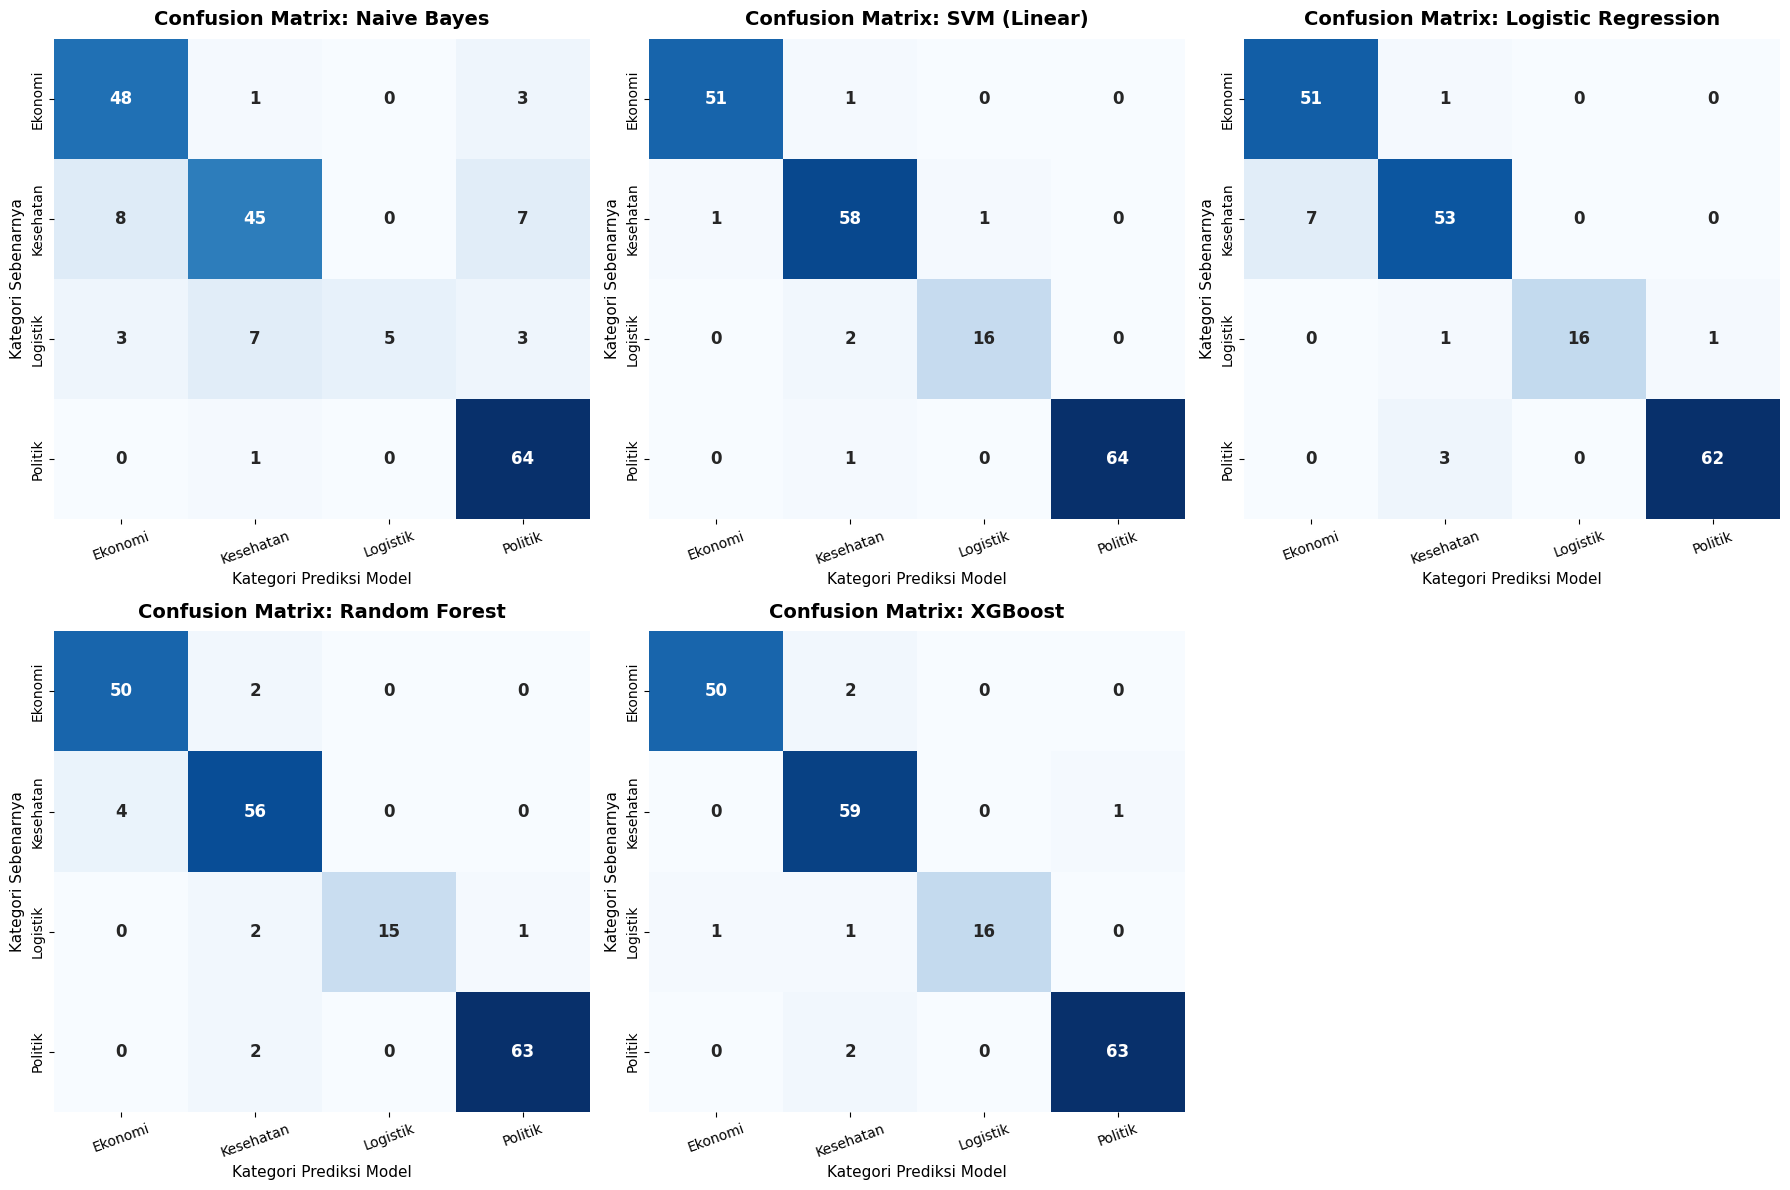

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Definisikan daftar kelas/kategori sesuai urutan alfabetis label Anda
nama_kelas = sorted(y_test.unique())

# 2. Atur ukuran kanvas grid (2 baris, 3 kolom untuk menampung 5 model)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten() # Meratakan matriks indeks subplot agar mudah diakses dalam loop

# 3. Looping untuk membuat Confusion Matrix setiap model
for i, (nama_model, model) in enumerate(models.items()):
    ax = axes[i]

    # Ambil hasil prediksi ulang yang sesuai untuk tiap model
    if nama_model == "XGBoost":
        y_pred_encoded = model.predict(X_test_tfidf)
        y_pred_model = le.inverse_transform(y_pred_encoded)
    else:
        y_pred_model = model.predict(X_test_tfidf)

    # Hitung Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_model, labels=nama_kelas)

    # Visualisasikan dengan Heatmap Seaborn
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
        xticklabels=nama_kelas, yticklabels=nama_kelas,
        annot_kws={"size": 12, "weight": "bold"}
    )

    # Atur judul dan label per subplot
    ax.set_title(f'Confusion Matrix: {nama_model}', fontsize=14, pad=10, weight='bold')
    ax.set_ylabel('Kategori Sebenarnya', fontsize=11)
    ax.set_xlabel('Kategori Prediksi Model', fontsize=11)
    ax.tick_params(axis='x', rotation=20) # Memiringkan teks label agar tidak bertumpuk

# 4. Sembunyikan kotak subplot ke-6 (indeks ke-5) karena hanya ada 5 model
axes[5].axis('off')

# 5. Atur tata letak otomatis agar tidak saling tumpang tindih
plt.tight_layout()
plt.show()

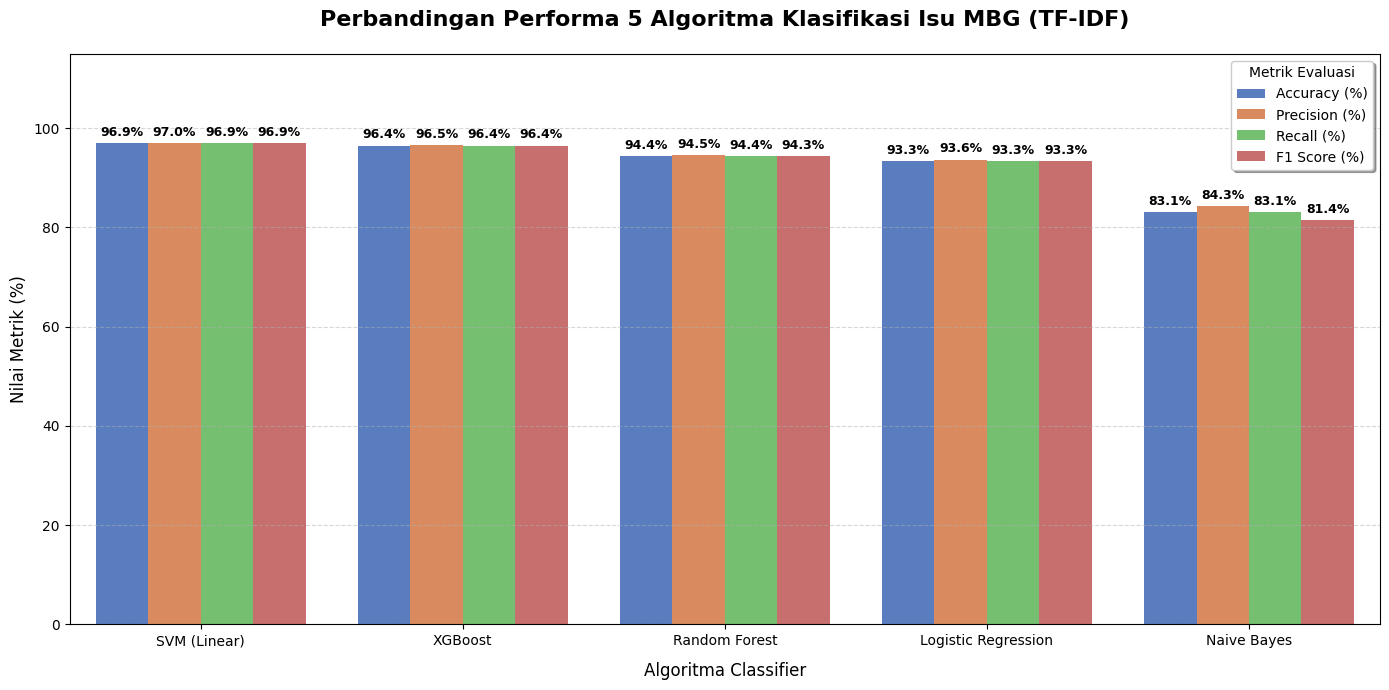

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengubah struktur dataframe hasil agar cocok untuk grafik grouped bar plot
# Kita ubah dari format melebar (wide) menjadi memanjang (long format)
df_melted = df_hasil.melt(
    id_vars="Model",
    var_name="Metrik",
    value_name="Nilai (%)"
)

# 2. Atur ukuran kanvas grafik
plt.figure(figsize=(14, 7))

# 3. Buat grouped bar plot menggunakan seaborn
ax = sns.barplot(
    data=df_melted,
    x="Model",
    y="Nilai (%)",
    hue="Metrik",
    palette="muted"
)

# 4. Tambahkan label nilai di atas setiap batang grafik secara otomatis
for p in ax.patches:
    if p.get_height() > 0: # Hanya beri label jika nilai di atas 0
        ax.annotate(
            f"{p.get_height():.1f}%",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=9,
            weight='bold'
        )

# 5. Atur dekorasi, judul, dan legenda grafik
plt.title('Perbandingan Performa 5 Algoritma Klasifikasi Isu MBG (TF-IDF)', fontsize=16, pad=20, weight='bold')
plt.xlabel('Algoritma Classifier', fontsize=12, labelpad=10)
plt.ylabel('Nilai Metrik (%)', fontsize=12)
plt.ylim(0, 115) # Beri ruang vertikal tambahan di atas batang untuk teks label
plt.legend(title="Metrik Evaluasi", loc="upper right", frameon=True, shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 6. Tampilkan grafik
plt.tight_layout()
plt.show()

## **Bagian Tambahan: Fungsi Pengujian Model Secara Real-Time (Inference Task)**

Tahapan ini merupakan proses pembuktian hilir (*deployment simulation*) di mana model klasifikasi yang telah dilatih diuji menggunakan data opini baru yang belum pernah dilihat oleh sistem sebelumnya.

### **Alur Kerja Fungsi Prediksi Singkat:**
1. **Defensif Validasi Global**: Fungsi secara cerdas memeriksa ketersediaan objek model **SVM (Linear)** di dalam memori lokal. Jika objek belum terlatih, sistem secara otomatis melakukan inisialisasi dan pelatihan kilat menggunakan matriks `X_train_tfidf`.
2. **Penyelarasan Pipeline Preprocessing**: Kalimat twit mentah yang diinput oleh pengguna wajib melewati fungsi `preprocess_text` untuk mengalami standardisasi (pembersihan tanda baca, lowercasing, pembuangan kata umum, dan pencarian kata dasar).
3. **Penyelarasan Dimensi Vektor (Strict Inference Rule)**: Teks bersih ditransformasikan menggunakan fungsi `transform()` dari `tfidf_vectorizer` yang telah dilatih sebelumnya. Aturan ini mutlak agar jumlah dimensi kata kunci baru (fitur kosakata) konsisten dan sinkron dengan dimensi data latihan model.
4. **Ekstraksi Hasil**: Model memprediksi koordinat fitur baru tersebut di dalam ruang *hyperplane*, lalu mengekstrak indeks array pertama `[0]` untuk memunculkan string label aspek final.

### **Analisis Kasus Uji Real-Time:**
*   **Twit Uji**: *"Pencopotan Dadan Hindayana oleh Presiden Prabowo akibat pelanggaran SOP dan buruknya tata kelola membuktikan bahwa kegagalan pelaksanaan program MBG..."*
*   **Target Prediksi Otomatis**: Berdasarkan bobot kemunculan kombinasi kata dasar seperti *"copot"*, *"presiden"*, *"prabowo"*, *"tata kelola"*, dan *"pimpinan"*, model SVM yang tangguh ini dirancang untuk mengarahkan dokumen tersebut secara instan ke dalam aspek **`Politik`** (atau `Ekonomi` tergantung kekuatan bobot kata korupsi/tata kelola). Ini membuktikan sistem berhasil bekerja sebagai instrumen pemantau isu strategis digital.


In [48]:
def uji_twit_baru(kalimat_twit):
    # Ensure model_svm is defined and trained
    global model_svm
    if 'model_svm' not in globals() or not hasattr(model_svm, 'predict'):
        print("Training SVM model for new prediction...")
        # Retrieve the LinearSVC model from the 'models' dictionary (from cell W8MWn3kMXN6z)
        model_svm = models["SVM (Linear)"]
        # Train the model with the training data
        model_svm.fit(X_train_tfidf, y_train)

    # 1. Gunakan fungsi pra-pemrosesan yang sudah kita buat di awal
    # Pastikan fungsi 'preprocess_text' di sel sebelumnya sudah dijalankan
    tokens_baru = preprocess_text(kalimat_twit)

    # 2. Gabungkan token menjadi string kalimat utuh
    teks_bersih = ' '.join(tokens_baru)

    # 3. Transformasikan teks menggunakan TfidfVectorizer yang sudah dilatih (fit)
    teks_tfidf = tfidf_vectorizer.transform([teks_bersih])

    # 4. Lakukan prediksi menggunakan model SVM yang sudah dilatih
    prediksi_label = model_svm.predict(teks_tfidf)[0]

    # 5. Tampilkan hasil output yang rapi
    print("=" * 50)
    print(f"Twit Input : \"{kalimat_twit}\"")
    print(f"Prediksi Aspek: {prediksi_label}")
    print("=" * 50)

# --- CONTOH PENGUJIAN ---
# Anda bisa mengganti kalimat di bawah ini untuk mencoba kalimat lainnya
twit_test = "Pencopotan Dadan Hindayana oleh Presiden Prabowo akibat pelanggaran SOP dan buruknya tata kelola membuktikan bahwa kegagalan pelaksanaan program MBG di lapangan bukan sekadar masalah teknis, melainkan cerminan dari lemahnya pengawasan dari pimpinan BGN"
uji_twit_baru(twit_test)

Twit Input : "Pencopotan Dadan Hindayana oleh Presiden Prabowo akibat pelanggaran SOP dan buruknya tata kelola membuktikan bahwa kegagalan pelaksanaan program MBG di lapangan bukan sekadar masalah teknis, melainkan cerminan dari lemahnya pengawasan dari pimpinan BGN"
Prediksi Aspek: Politik


In [49]:
print(df_gabungan['full_text'])

0       Rapidin Simbolon Usul Dana Makan Bergizi Grati...
1       What was supposed to be a standard presentatio...
2       Program Makan Bergizi Gratis terseret kasus ko...
3       Personel Polsek Krueng Sabee Laksanakan Samban...
4       Masa depan cerah Indonesia dimulai dari asupan...
                              ...                        
1035    Wacana Program Makan Bergizi Gratis (MBG) bagi...
1036    Sekitar 9 orang penyidik Jaksa Agung Muda Tind...
1037    Program Makan Bergizi Gratis hadir untuk memba...
1038    Presiden Prabowo Subianto resmi menunjuk Nanik...
1039    Kepala Staf Kepresidenan (KSP) Dudung Abdurach...
Name: full_text, Length: 1040, dtype: object
